# Multi-Year Consistency Check (2023-2025)
This notebook evaluates the same trained models on 3 sequential years to test consistency.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import os
from scipy.optimize import minimize

# Ensure plots look nice
plt.style.use('ggplot')

In [2]:
# Load Multi-Asset Data
file_path = 'real_crypto_data.csv'
try:
    df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')
    print("Loaded Assets:", df.columns.tolist())
except FileNotFoundError:
    print("File not found. Generating dummy.")
    dates = pd.date_range(start='2023-01-01', periods=1095)
    df = pd.DataFrame(np.random.randn(1095, 5), index=dates, columns=['BTC','ETH','XRP','LTC','BCH'])
    df = (1 + df.pct_change().fillna(0)).cumprod() * 100

def get_market_features(df):
    returns = df.pct_change().fillna(0)
    volatility = returns.rolling(window=20).std().fillna(0)
    sma50 = df.rolling(window=50).mean()
    momentum = (df / sma50 - 1).fillna(0)
    return returns, volatility, momentum

returns_df, vol_df, mom_df = get_market_features(df)
assets = df.columns.tolist()
n_assets = len(assets)

# Split Data (70% Train, 30% Test for Model Training purposes)
# But we will evaluate on specific years later
train_split_idx = int(len(df) * 0.7)
train_df_slice = df.iloc[:train_split_idx]
train_returns_slice = returns_df.iloc[:train_split_idx]
train_vol_slice = vol_df.iloc[:train_split_idx]
train_mom_slice = mom_df.iloc[:train_split_idx]

print(f"Total Data Points: {len(df)}")
print(f"Training Split Index: {train_split_idx}")

Loaded Assets: ['BCH', 'BTC', 'ETH', 'LTC', 'XRP']
Total Data Points: 1096
Training Split Index: 767


In [3]:
class MultiAssetCryptoEnv(gym.Env):
    def __init__(self, price_df, returns_df, vol_df, mom_df):
        super(MultiAssetCryptoEnv, self).__init__()
        self.price_df = price_df
        self.returns_df = returns_df
        self.vol_df = vol_df
        self.mom_df = mom_df
        self.assets = price_df.columns
        self.n_assets = len(self.assets)
        self.action_space = spaces.Box(low=0, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.n_assets * 3,), dtype=np.float32)
        self.current_step = 0
        self.max_steps = len(price_df) - 1

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        r = self.returns_df.iloc[self.current_step].values
        v = self.vol_df.iloc[self.current_step].values
        m = self.mom_df.iloc[self.current_step].values
        return np.concatenate([r, v, m]).astype(np.float32)

    def step(self, action):
        weights = np.exp(action) / np.sum(np.exp(action))
        asset_weights = weights[:-1]
        cash_weight = weights[-1]
        
        if self.current_step >= self.max_steps:
            return self._get_obs(), 0, True, False, {}
            
        next_day_returns = self.returns_df.iloc[self.current_step + 1].values
        portfolio_return = np.sum(asset_weights * next_day_returns)
        reward = np.log(1 + portfolio_return)
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        info = {'return': portfolio_return, 'weights': asset_weights, 'cash': cash_weight}
        return self._get_obs(), reward, terminated, False, info

# LSTM Predictor Model (PyTorch)
class LSTMPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMPredictor, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = self.dropout(hn[-1])
        out = self.fc(out)
        return out

In [4]:
# 1. Load Standard PPO (Baseline)
model_path = "./best_model_ppo/best_model"
# Create a dummy env for loading/init
dummy_env = MultiAssetCryptoEnv(train_df_slice, train_returns_slice, train_vol_slice, train_mom_slice)
dummy_env = DummyVecEnv([lambda: dummy_env])

if os.path.exists(model_path + ".zip"):
    model_baseline = PPO.load(model_path)
    print("Loaded DeepRL PPO (Baseline).")
else:
    print("Baseline model not found! Using dummy baseline.")
    model_baseline = PPO("MlpPolicy", dummy_env)

# 2. Train Enhanced PPO (Linear LR + High Entropy)
def linear_schedule(initial_value):
    if isinstance(initial_value, str):
        initial_value = float(initial_value)
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func

print("Training DeepRL PPO (Enhanced)...\nParams: ent_coef=0.05, lr=Linear Schedule")

model_enhanced = PPO(
    "MlpPolicy", 
    dummy_env, 
    verbose=0, 
    ent_coef=0.05,
    learning_rate=linear_schedule(3e-4)
)
model_enhanced.learn(total_timesteps=10000)
print("DeepRL PPO (Enhanced) Training Complete.")

Baseline model not found! Using dummy baseline.
Training DeepRL PPO (Enhanced)...
Params: ent_coef=0.05, lr=Linear Schedule
DeepRL PPO (Enhanced) Training Complete.


In [5]:
# --- AI-Gated Classifier Training (Random Forest) ---
# We train on the Training Split (to simulate what we knew back then), 
# but we generate probabilities for the ENTIRE dataset to evaluate consistency across all years.

print('Training AI Gatekeeper (Bul/Bear Classifier)...')
market_ret = returns_df.mean(axis=1)
feat = pd.DataFrame(index=returns_df.index)
feat['Vol_20'] = market_ret.rolling(20).std()
feat['Mom_20'] = market_ret.rolling(20).mean()
feat['Target'] = (market_ret.shift(-1) > 0).astype(int)
feat = feat.dropna()

X_rf = feat[['Vol_20', 'Mom_20']]
y_rf = feat['Target']

# Train on Training Split ONLY
train_mask = X_rf.index.isin(train_df_slice.index)
X_train_rf = X_rf[train_mask]
y_train_rf = y_rf[train_mask]

clf = RandomForestClassifier(n_estimators=100, min_samples_split=10, random_state=42)
clf.fit(X_train_rf, y_train_rf)

# Predict on ALL data
rf_probs_all = clf.predict_proba(X_rf)[:, 1]
rf_probs_series = pd.Series(rf_probs_all, index=X_rf.index)
print(f'AI Gatekeeper Trained. Train Acc: {accuracy_score(y_train_rf, clf.predict(X_train_rf)):.2f}')

# --- Deep Learning (LSTM) Training ---
print('Training LSTM Predictor...')
LOOKBACK = 10
def create_dataset(dataset, look_back=10):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, :])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

# Train on Training Split Only
train_data_val = returns_df.iloc[:train_split_idx].values
X_train_lstm, y_train_lstm = create_dataset(train_data_val, LOOKBACK)

train_dataset = TensorDataset(torch.from_numpy(X_train_lstm), torch.from_numpy(y_train_lstm))
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

lstm_model = LSTMPredictor(input_dim=n_assets, hidden_dim=64, output_dim=n_assets)
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

lstm_model.train()
for epoch in range(20):
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

# Predict on ALL data
X_all_lstm, _ = create_dataset(returns_df.values, LOOKBACK)
lstm_model.eval()
with torch.no_grad():
    pred_all_tensor = lstm_model(torch.from_numpy(X_all_lstm))
    pred_all_numpy = pred_all_tensor.numpy()

# Map predictions to dates
# We create a dataframe where index = Date of predicted return
valid_lstm_indices = range(LOOKBACK, LOOKBACK + len(pred_all_numpy))
valid_dates = returns_df.index[valid_lstm_indices]
lstm_preds_df = pd.DataFrame(pred_all_numpy, index=valid_dates, columns=assets)

print('LSTM Training Complete. Predictions generated for full period.')

# Helper for Markowitz
def optimize_markowitz(returns_window, cov_matrix):
    n = returns_window.shape[1]
    if n == 0: return []
    def neg_sharpe(weights):
        fed_return = np.sum(returns_window.mean() * weights) * 252
        fed_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
        return -(fed_return / fed_vol) if fed_vol > 0 else 0
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    try:
        res = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return res.x
    except:
        return init_guess

Training AI Gatekeeper (Bul/Bear Classifier)...
AI Gatekeeper Trained. Train Acc: 0.90
Training LSTM Predictor...
LSTM Training Complete. Predictions generated for full period.


In [6]:
def run_year_evaluation(year_str, eval_df, eval_returns, eval_vol, eval_mom):
    print(f"\n{'='*10} Evaluating Year: {year_str} (Trading Days: {len(eval_df)}) {'='*10}")
    if len(eval_df) < 50:
        print("Not enough data to evaluate.")
        return None

    # Init Env for this specific year
    env_eval = MultiAssetCryptoEnv(eval_df, eval_returns, eval_vol, eval_mom)
    obs, _ = env_eval.reset()

    portfolio_values = {
        'DeepRL PPO (Baseline)': [100.0],
        'DeepRL PPO (Enhanced)': [100.0],
        'Markowitz': [100.0],
        'AI-Gated Markowitz (RF)': [100.0],
        'DL-Markowitz (LSTM)': [100.0],
        'Trend-Based (Markowitz/Cash)': [100.0],
        'Equal Weight': [100.0],
        'Buy and Hold': [100.0]
    }
    bnh_holdings = np.ones(n_assets) * (100.0 / n_assets) 

    # Lookback for rolling windows (Markowitz covariance)
    lookback = 50

    # Simulation Loop
    for step in range(len(eval_df) - 1):
        current_date = eval_df.index[step]
        
        # 1. PPO Baseline
        action_base, _ = model_baseline.predict(obs, deterministic=True)
        
        # 2. PPO Enhanced
        action_enh, _ = model_enhanced.predict(obs, deterministic=True)
        weights_enh = np.exp(action_enh) / np.sum(np.exp(action_enh))
        asset_weights_enh = weights_enh[:-1]
        
        # Step Environment
        obs, reward, done, _, info = env_eval.step(action_base)
        
        # --- Update Portfolios ---
        
        # Get actual returns for next day being simulated
        if step + 1 < len(eval_returns):
            day_returns = eval_returns.iloc[step + 1].values
        else:
            day_returns = np.zeros(n_assets)

        # Baseline
        ret_base = info['return']
        portfolio_values['DeepRL PPO (Baseline)'].append(portfolio_values['DeepRL PPO (Baseline)'][-1] * (1 + ret_base))
        
        # Enhanced
        ret_enh = np.sum(asset_weights_enh * day_returns)
        portfolio_values['DeepRL PPO (Enhanced)'].append(portfolio_values['DeepRL PPO (Enhanced)'][-1] * (1 + ret_enh))
            
        # Traditional Baselines
        # Covariance requires history. We use the 'eval_returns' slice up to current step.
        # This means at the start of the year, window is small. 
        # Ideally we should pass full history, but keeping it isolated per year is a valid "Stress Test" 
        # (simulating starting a new fund that year).
        if step >= lookback:
            window_ret = eval_returns.iloc[step-lookback:step]
            cov_mat = window_ret.cov().values
            mw_weights = optimize_markowitz(window_ret, cov_mat)
        else:
            mw_weights = np.ones(n_assets) / n_assets
        
        ret_mw = np.sum(mw_weights * day_returns)
        portfolio_values['Markowitz'].append(portfolio_values['Markowitz'][-1] * (1 + ret_mw))

        # AI-Gated
        if current_date in rf_probs_series.index:
            bull_prob = rf_probs_series.loc[current_date]
            if bull_prob > 0.52: ai_mw_w = mw_weights
            elif bull_prob < 0.48: ai_mw_w = 0.0 # Bear
            else: ai_mw_w = 0.5 * mw_weights
        else:
            ai_mw_w = 0.5 * mw_weights
        ret_ai = np.sum(ai_mw_w * day_returns)
        portfolio_values['AI-Gated Markowitz (RF)'].append(portfolio_values['AI-Gated Markowitz (RF)'][-1] * (1 + ret_ai))

        # DL-Markowitz (LSTM)
        # Using pre-calculated predictions
        # We need prediction for T+1
        target_date_idx = step + 1
        ret_dl = 0.0
        if target_date_idx < len(eval_df):
            target_date = eval_df.index[target_date_idx]
            if target_date in lstm_preds_df.index:
                pred_ret = lstm_preds_df.loc[target_date].values
                # Optimization
                def optimize_dl(exp_ret, cov):
                    n = len(exp_ret)
                    def neg_sharpe(w):
                        fr = np.sum(exp_ret * w)
                        fv = np.sqrt(np.dot(w.T, np.dot(cov, w)))
                        return -(fr / (fv + 1e-6))
                    c = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
                    b = tuple((0, 1) for _ in range(n))
                    i = n * [1. / n]
                    try: res = minimize(neg_sharpe, i, method='SLSQP', bounds=b, constraints=c); return res.x
                    except: return i
                
                if step >= lookback:
                     dl_w = optimize_dl(pred_ret, cov_mat)
                else:
                     dl_w = np.ones(n_assets) / n_assets
                
                ret_dl = np.sum(dl_w * day_returns)
        
        portfolio_values['DL-Markowitz (LSTM)'].append(portfolio_values['DL-Markowitz (LSTM)'][-1] * (1 + ret_dl))

        # Trend-Based
        current_mom = np.mean(eval_mom.iloc[step].values)
        if current_mom > 0: trend_weights = mw_weights
        else: trend_weights = 0.5 * mw_weights
        ret_trend = np.sum(trend_weights * day_returns)
        portfolio_values['Trend-Based (Markowitz/Cash)'].append(portfolio_values['Trend-Based (Markowitz/Cash)'][-1] * (1 + ret_trend))
        
        # Equal Weight
        ew_weights = np.ones(n_assets) / n_assets
        ret_ew = np.sum(ew_weights * day_returns)
        portfolio_values['Equal Weight'].append(portfolio_values['Equal Weight'][-1] * (1 + ret_ew))
        
        # Buy and Hold
        bnh_holdings = bnh_holdings * (1 + day_returns)
        portfolio_values['Buy and Hold'].append(np.sum(bnh_holdings))
        
    return portfolio_values


========== Evaluating Year: 2023 (Trading Days: 365) ==========

========== Evaluating Year: 2024 (Trading Days: 366) ==========

========== Evaluating Year: 2025 (Trading Days: 365) ==========

>>> PERFORMANCE REPORT YEAR: 2023 <<<
                             Total Return Volatility Sharpe Ratio
DeepRL PPO (Baseline)              85.83%     41.93%         1.69
DeepRL PPO (Enhanced)              86.96%     41.63%         1.71
Markowitz                         116.39%     56.58%         1.65
AI-Gated Markowitz (RF)          1973.07%     40.61%         7.71
DL-Markowitz (LSTM)                17.01%     66.59%         0.56
Trend-Based (Markowitz/Cash)       60.31%     46.10%         1.25
Equal Weight                      106.09%     50.32%         1.69
Buy and Hold                       99.19%     49.40%         1.64


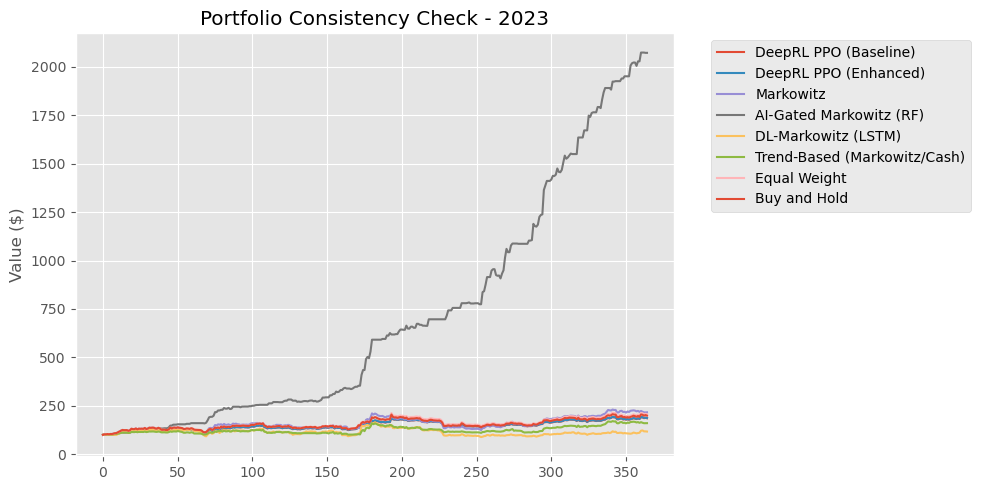


>>> PERFORMANCE REPORT YEAR: 2024 <<<
                             Total Return Volatility Sharpe Ratio
DeepRL PPO (Baseline)              87.40%     50.47%         1.50
DeepRL PPO (Enhanced)              84.79%     50.04%         1.48
Markowitz                          77.78%     63.36%         1.22
AI-Gated Markowitz (RF)          2461.16%     46.41%         7.24
DL-Markowitz (LSTM)               392.62%     92.96%         2.14
Trend-Based (Markowitz/Cash)       74.31%     51.29%         1.34
Equal Weight                      106.12%     60.55%         1.50
Buy and Hold                       96.79%     61.32%         1.41


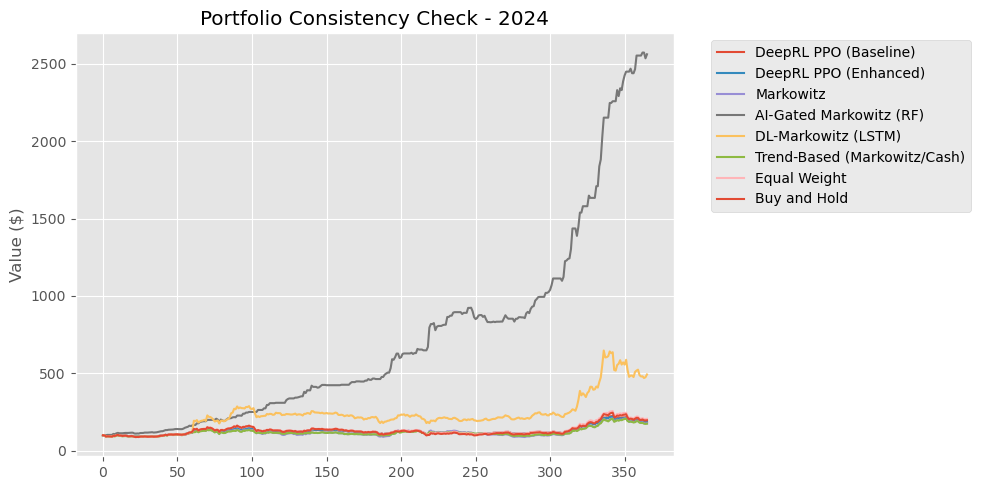


>>> PERFORMANCE REPORT YEAR: 2025 <<<
                             Total Return Volatility Sharpe Ratio
DeepRL PPO (Baseline)               1.10%     50.49%         0.27
DeepRL PPO (Enhanced)               1.34%     50.38%         0.28
Markowitz                           1.97%     68.99%         0.37
AI-Gated Markowitz (RF)           162.84%     59.62%         1.92
DL-Markowitz (LSTM)               -18.04%     69.01%         0.06
Trend-Based (Markowitz/Cash)        8.77%     48.91%         0.41
Equal Weight                       -1.74%     60.59%         0.28
Buy and Hold                       -6.61%     60.18%         0.19


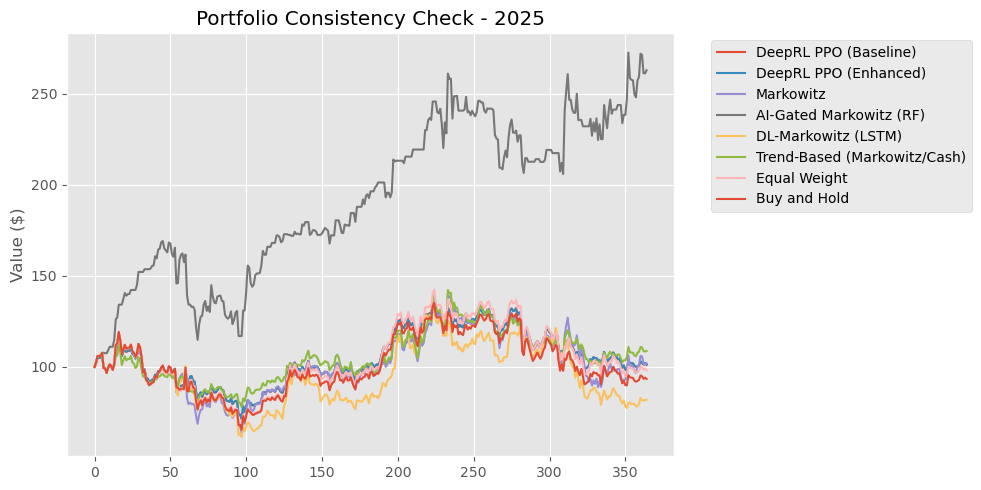

In [7]:
years_to_test = [2023, 2024, 2025]
results_by_year = {}

for year in years_to_test:
    mask = df.index.year == year
    df_y = df[mask]
    if len(df_y) > 0:
        ret_y = returns_df[mask]
        vol_y = vol_df[mask]
        mom_y = mom_df[mask]
        
        res = run_year_evaluation(str(year), df_y, ret_y, vol_y, mom_y)
        if res is not None:
            results_by_year[year] = res

# --- Metric Calculation ---
metric_cols = ['Total Return', 'Volatility', 'Sharpe Ratio']

def calculate_metrics(p_values_dict):
    metrics = {}
    for name, values in p_values_dict.items():
        arr = np.array(values)
        if len(arr) < 2: continue
        rets = arr[1:] / arr[:-1] - 1
        if len(rets) == 0: continue
        
        total_ret = (arr[-1] / arr[0]) - 1
        vol = np.std(rets) * np.sqrt(365) # Crypto 365
        if np.std(rets) > 1e-6:
            sharpe = (np.mean(rets) / np.std(rets)) * np.sqrt(365)
        else:
            sharpe = 0.0
        
        metrics[name] = [total_ret, vol, sharpe]
    return pd.DataFrame(metrics, index=metric_cols).T

# Display Tables
for year in sorted(results_by_year.keys()):
    print(f"\n>>> PERFORMANCE REPORT YEAR: {year} <<<")
    res = results_by_year[year]
    df_metrics = calculate_metrics(res)
    
    # Format for display
    df_fmt = df_metrics.copy()
    for c in ['Total Return', 'Volatility']:
        df_fmt[c] = df_fmt[c].apply(lambda x: f"{x:.2%}")
    df_fmt['Sharpe Ratio'] = df_fmt['Sharpe Ratio'].apply(lambda x: f"{x:.2f}")
    
    print(df_fmt)
    
    # Optional Plot per year
    plt.figure(figsize=(10, 5))
    for name, values in res.items():
        plt.plot(values, label=name)
    plt.title(f"Portfolio Consistency Check - {year}")
    plt.ylabel("Value ($)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()